In [1]:
# libraries
import os
import pandas as pd
import numpy as np
import pickle

os.chdir("/home/zmk214/data/projects/nucleiCAGEproject/7.Meena_v3/model_Meena_v3_development")

from lightgbm import LGBMClassifier
from sklearn.utils import shuffle
from pythonfn_prepInput_v3_1 import readInProfiles
from pythonfn_prepInput_v3_1 import readInMetadata

seed = 0
np.random.seed(seed)

#dir_prfl = "/home/zmk214/zmk214/nucleiCAGE_wd/R_prepData_Meena_CAGE_DHS_forModelTraining_v2/Meena_v2/profiles_subtnorm/"


modelname = 'model_Meena_v3_gm12878.sav'


dir_mtdt = "/home/zmk214/data/projects/nucleiCAGEproject/7.Meena_v3/Meena_v3/metadata_subtnorm/"
dir_prfl = "/home/zmk214/data/projects/nucleiCAGEproject/7.Meena_v3/Meena_v3/profiles_subtnorm/"

keep_word = ['GM12878_reseq']
remove_word = False

te_pos_prfl = readInProfiles(dir_prfl + "vl.pos/", setName="validation-positive profiles", withAug=False, withWord=keep_word, withoutWord=remove_word)
te_neg_prfl = readInProfiles(dir_prfl + "vl.neg/", setName="validation-negative profiles", withAug=False, withWord=keep_word, withoutWord=remove_word)

te_pos_mtdt = readInProfiles(dir_mtdt + "vl.pos/", setName="validation-positive profiles", withAug=False, withWord=keep_word, withoutWord=remove_word)
te_neg_mtdt = readInProfiles(dir_mtdt + "vl.neg/", setName="validation-negative profiles", withAug=False, withWord=keep_word, withoutWord=remove_word)


te_pos_prfl.reset_index(inplace=True, drop=True)
te_neg_prfl.reset_index(inplace=True, drop=True)

te_pos_mtdt.reset_index(inplace=True, drop=True)
te_neg_mtdt.reset_index(inplace=True, drop=True)

validation-positive profiles
check
no remove word
profiles_vl.pos.GM12878_reseq_C_1mio_1.csv contains 5967 rows
profiles_vl.pos.GM12878_reseq_C_1mio_2.csv contains 6567 rows
profiles_vl.pos.GM12878_reseq_C_1mio_3.csv contains 9654 rows
profiles_vl.pos.GM12878_reseq_C_500k_1.csv contains 10030 rows
profiles_vl.pos.GM12878_reseq_C_500k_2.csv contains 6719 rows
profiles_vl.pos.GM12878_reseq_C_500k_3.csv contains 7290 rows
profiles_vl.pos.GM12878_reseq_N_10mio_1.csv contains 30151 rows
profiles_vl.pos.GM12878_reseq_N_10mio_2.csv contains 22273 rows
profiles_vl.pos.GM12878_reseq_N_10mio_3.csv contains 34519 rows
profiles_vl.pos.GM12878_reseq_N_1mio_1.csv contains 6647 rows
profiles_vl.pos.GM12878_reseq_N_1mio_2.csv contains 6864 rows
profiles_vl.pos.GM12878_reseq_N_1mio_3.csv contains 5924 rows
profiles_vl.pos.GM12878_reseq_N_5mio_1.csv contains 15436 rows
profiles_vl.pos.GM12878_reseq_N_5mio_2.csv contains 16037 rows
profiles_vl.pos.GM12878_reseq_N_5mio_3.csv contains 11295 rows
In total, 

In [2]:
def manage_mtdt(df):
    split_lib = df['lib'].str.split('_', n=1, expand=True)
    df['celllines'] = split_lib[0]
    df['remaining_text'] = split_lib[1]
    df['cage'] = df['remaining_text'].apply(lambda x: 'N' if 'N' in x else ('C' if 'C' in x else None))
    df.drop('remaining_text', axis=1, inplace=True)
    return(df)

In [3]:
te_pos_mtdt_mdf = manage_mtdt(te_pos_mtdt)
te_neg_mtdt_mdf = manage_mtdt(te_neg_mtdt)

In [4]:
te_pos_mtdt_mdf

,chr,atac_start,atac_txType,lib,setname,celllines,cage
0,chr1,904520,promoter,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C
1,chr1,1019369,proximal,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C
2,chr1,1058992,proximal,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C
3,chr1,1059540,promoter,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C
4,chr1,1157805,intergenic,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C
...,...,...,...,...,...,...,...
195368,chrX,154762943,promoter,GM12878_reseq_N_5mio_3,vl.pos,GM12878,N
195369,chrX,155069389,intron,GM12878_reseq_N_5mio_3,vl.pos,GM12878,N
195370,chrX,155611995,proximal,GM12878_reseq_N_5mio_3,vl.pos,GM12878,N
195371,chrM,6912,proximal,GM12878_reseq_N_5mio_3,vl.pos,GM12878,N


In [5]:
model = pickle.load(open(modelname, 'rb'))

In [6]:
def add_pred(mod, prfl, mtdt, intLabel):
    y_proba = mod.predict_proba(prfl)[:,1]
    y_pred = mod.predict(prfl)
    mtdt['y_proba'] = y_proba
    mtdt['y_pred'] = y_pred
    mtdt['y_true'] = [intLabel]*len(prfl)
    return(mtdt)

In [7]:
pos = add_pred(model, te_pos_prfl, te_pos_mtdt, 1)
pos

,chr,atac_start,atac_txType,lib,setname,celllines,cage,y_proba,y_pred,y_true
0,chr1,904520,promoter,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.797386,1,1
1,chr1,1019369,proximal,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.592146,1,1
2,chr1,1058992,proximal,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.469712,0,1
3,chr1,1059540,promoter,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.920028,1,1
4,chr1,1157805,intergenic,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.819521,1,1
...,...,...,...,...,...,...,...,...,...,...
195368,chrX,154762943,promoter,GM12878_reseq_N_5mio_3,vl.pos,GM12878,N,0.616989,1,1
195369,chrX,155069389,intron,GM12878_reseq_N_5mio_3,vl.pos,GM12878,N,0.440015,0,1
195370,chrX,155611995,proximal,GM12878_reseq_N_5mio_3,vl.pos,GM12878,N,0.600259,1,1
195371,chrM,6912,proximal,GM12878_reseq_N_5mio_3,vl.pos,GM12878,N,0.961886,1,1


In [8]:
neg = add_pred(model, te_neg_prfl, te_neg_mtdt, 0)
neg

,chr,atac_start,atac_txType,lib,setname,celllines,cage,y_proba,y_pred,y_true
0,chr1,630880,promoter,GM12878_reseq_C_1mio_1,vl.neg,GM12878,C,0.520022,1,0
1,chr1,960040,proximal,GM12878_reseq_C_1mio_1,vl.neg,GM12878,C,0.461379,0,0
2,chr1,1540432,promoter,GM12878_reseq_C_1mio_1,vl.neg,GM12878,C,0.011405,0,0
3,chr1,1564426,threeUTR,GM12878_reseq_C_1mio_1,vl.neg,GM12878,C,0.423513,0,0
4,chr1,1649322,CDS,GM12878_reseq_C_1mio_1,vl.neg,GM12878,C,0.443468,0,0
...,...,...,...,...,...,...,...,...,...,...
195368,chrY,4986038,intergenic,GM12878_reseq_N_5mio_3,vl.neg,GM12878,N,0.454566,0,0
195369,chrY,10788780,intergenic,GM12878_reseq_N_5mio_3,vl.neg,GM12878,N,0.424398,0,0
195370,chrY,10987722,intergenic,GM12878_reseq_N_5mio_3,vl.neg,GM12878,N,0.015334,0,0
195371,chrY,11291307,intergenic,GM12878_reseq_N_5mio_3,vl.neg,GM12878,N,0.565832,1,0


In [9]:
te = pd.concat([pos, neg], ignore_index=True)
te

,chr,atac_start,atac_txType,lib,setname,celllines,cage,y_proba,y_pred,y_true
0,chr1,904520,promoter,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.797386,1,1
1,chr1,1019369,proximal,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.592146,1,1
2,chr1,1058992,proximal,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.469712,0,1
3,chr1,1059540,promoter,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.920028,1,1
4,chr1,1157805,intergenic,GM12878_reseq_C_1mio_1,vl.pos,GM12878,C,0.819521,1,1
...,...,...,...,...,...,...,...,...,...,...
390741,chrY,4986038,intergenic,GM12878_reseq_N_5mio_3,vl.neg,GM12878,N,0.454566,0,0
390742,chrY,10788780,intergenic,GM12878_reseq_N_5mio_3,vl.neg,GM12878,N,0.424398,0,0
390743,chrY,10987722,intergenic,GM12878_reseq_N_5mio_3,vl.neg,GM12878,N,0.015334,0,0
390744,chrY,11291307,intergenic,GM12878_reseq_N_5mio_3,vl.neg,GM12878,N,0.565832,1,0


In [10]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, fbeta_score

In [11]:
confusion_matrix(te['y_true'], te['y_pred'])

array([[124252,  71121],
       [ 65359, 130014]])

In [12]:
# all te
print(classification_report(te['y_true'], te['y_pred']))

              precision    recall  f1-score   support

           0       0.66      0.64      0.65    195373
           1       0.65      0.67      0.66    195373

    accuracy                           0.65    390746
   macro avg       0.65      0.65      0.65    390746
weighted avg       0.65      0.65      0.65    390746



In [13]:
# each cell types
col = 'celllines'
ls = list(set(te[col]))
for i in ls:
    slt = te[te[col] == i]
    print(i)
    print(classification_report(slt['y_true'], slt['y_pred']))

GM12878
              precision    recall  f1-score   support

           0       0.66      0.64      0.65    195373
           1       0.65      0.67      0.66    195373

    accuracy                           0.65    390746
   macro avg       0.65      0.65      0.65    390746
weighted avg       0.65      0.65      0.65    390746



In [14]:
# each ccage
col = 'cage'
ls = list(set(te[col]))
for i in ls:
    slt = te[te[col] == i]
    print(i)
    print(classification_report(slt['y_true'], slt['y_pred']))

N
              precision    recall  f1-score   support

           0       0.66      0.62      0.64    149146
           1       0.64      0.68      0.66    149146

    accuracy                           0.65    298292
   macro avg       0.65      0.65      0.65    298292
weighted avg       0.65      0.65      0.65    298292

C
              precision    recall  f1-score   support

           0       0.64      0.68      0.66     46227
           1       0.66      0.62      0.64     46227

    accuracy                           0.65     92454
   macro avg       0.65      0.65      0.65     92454
weighted avg       0.65      0.65      0.65     92454



In [15]:
# each annotation

col = 'atac_txType'
ls = list(set(te_pos_mtdt_mdf['atac_txType']))
for i in ls:
    slt = te[te[col] == i]
    print(i)
    print(classification_report(slt['y_true'], slt['y_pred']))


promoter
              precision    recall  f1-score   support

           0       0.48      0.47      0.48     14896
           1       0.83      0.84      0.83     46680

    accuracy                           0.75     61576
   macro avg       0.66      0.66      0.66     61576
weighted avg       0.75      0.75      0.75     61576

proximal
              precision    recall  f1-score   support

           0       0.51      0.58      0.54     11275
           1       0.70      0.65      0.67     17637

    accuracy                           0.62     28912
   macro avg       0.61      0.61      0.61     28912
weighted avg       0.63      0.62      0.62     28912

intergenic
              precision    recall  f1-score   support

           0       0.69      0.73      0.71     31887
           1       0.63      0.58      0.60     24619

    accuracy                           0.67     56506
   macro avg       0.66      0.66      0.66     56506
weighted avg       0.66      0.67      0.67  

In [16]:
set_tx_pos = set(te_pos_mtdt_mdf['atac_txType'])
set_tx_neg = set(te_neg_mtdt_mdf['atac_txType'])

nonOverlap = sorted(list(set_tx_neg - set_tx_pos))
nonOverlap

['CDS', 'exon', 'threeUTR']

In [17]:
ls = nonOverlap
col = 'atac_txType'
for i in ls:
    slt = te[te[col] == i]
    print(i)
    cm = confusion_matrix(slt['y_true'], slt['y_pred'])
    print('True negative = ' + str(cm[0,0]) + ' -> ' + str(cm[0,0] / len(slt)))
    print('False positive = ' + str(cm[0,1]) + ' -> ' + str(cm[0,1] / len(slt)))
    print('\n')

CDS
True negative = 5662 -> 0.5805988515176375
False positive = 4090 -> 0.4194011484823626


exon
True negative = 3529 -> 0.6372336583604189
False positive = 2009 -> 0.3627663416395811


threeUTR
True negative = 8365 -> 0.5804593713135799
False positive = 6046 -> 0.4195406286864201




In [18]:
import matplotlib.pyplot as plt

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(te['y_true'], te['y_proba'])
roc_auc = auc(fpr, tpr)

# Compute Precision-Recall curve and area for each class
precision, recall, _ = precision_recall_curve(te['y_true'], te['y_proba'])
average_precision = average_precision_score(te['y_true'], te['y_proba'])

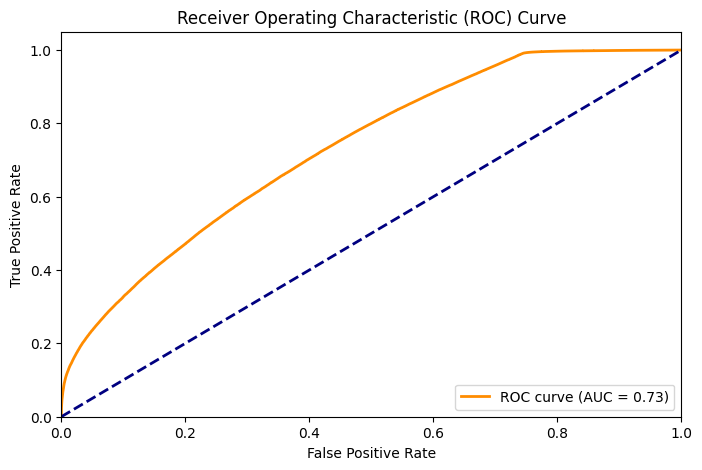

In [19]:
# Plot ROC curve
plt.figure(figsize=(8, 5))
#plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('modelEval_all.trvl_testingSet_ROC_curve.pdf')
plt.show()

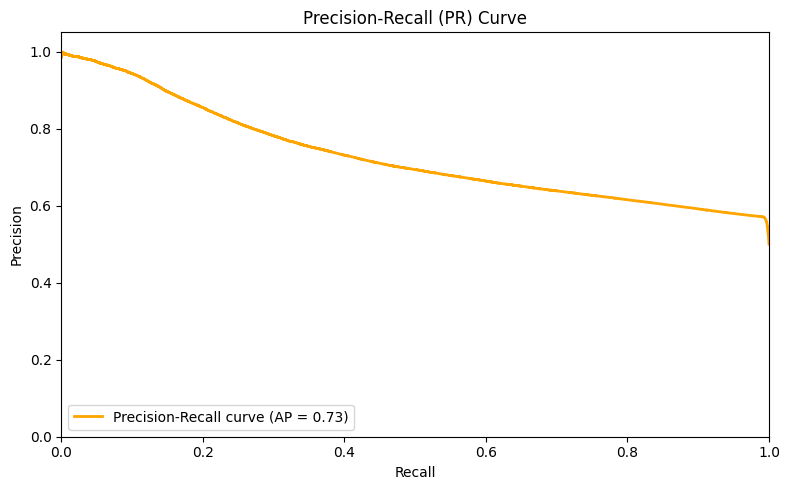

In [20]:
# Plot PR curve
#plt.subplot(1, 2, 2)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='orange', lw=2, label='Precision-Recall curve (AP = %0.2f)' % average_precision)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall (PR) Curve')
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig('modelEval_all.trvl_testingSet_pr_curve.pdf')
plt.show()

In [21]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
def getEvalTabel(te_df, col):
    pos_eval = pd.DataFrame()
    neg_eval = pd.DataFrame()
    weighted_avg_eval = pd.DataFrame()
    
    ls = list(set(te_df[col]))
    for i in ls:
        slt = te_df[te_df[col] == i]
        #print(i)
        #print(classification_report(slt['y_true'], slt['y_pred']))
        report_dict = classification_report(slt['y_true'], slt['y_pred'], output_dict=True)
        report_df = pd.DataFrame(report_dict)
        report_df = report_df.transpose()
    
        pos_eval = pos_eval.append(report_df.loc['1'])
        neg_eval = neg_eval.append(report_df.loc['0'])
        weighted_avg_eval = weighted_avg_eval.append(report_df.loc['weighted avg'])

    pos_eval.index = ls
    neg_eval.index = ls
    weighted_avg_eval.index = ls
    
    return(pos_eval, neg_eval, weighted_avg_eval)

In [23]:
pos_eval_ova = pd.DataFrame()
neg_eval_ova = pd.DataFrame()
weighted_avg_eval_ova = pd.DataFrame()
    
report_dict = classification_report(te['y_true'], te['y_pred'], output_dict=True)
report_df = pd.DataFrame(report_dict)
report_df = report_df.transpose()
    
pos_eval_ova = pos_eval_ova.append(report_df.loc['1'])
neg_eval_ova = neg_eval_ova.append(report_df.loc['0'])
weighted_avg_eval_ova = weighted_avg_eval_ova.append(report_df.loc['weighted avg'])

pos_eval_ova.index = ['overall']
neg_eval_ova.index = ['overall']
weighted_avg_eval_ova.index = ['overall']

In [24]:
weighted_avg_eval_ova

,precision,recall,f1-score,support
overall,0.650851,0.650719,0.650643,390746.0


In [25]:
pos_eval_cell, neg_eval_cell, weighted_avg_eval_cell = getEvalTabel(te, 'celllines')
pos_eval_cege, neg_eval_cege, weighted_avg_eval_cege = getEvalTabel(te, 'cage')

In [26]:
pos_eval_tx = pd.DataFrame()
neg_eval_tx = pd.DataFrame()
weighted_avg_eval_tx = pd.DataFrame()

col = 'atac_txType'
ls = list(set(te_pos_mtdt_mdf['atac_txType']))

for i in ls:
    slt = te[te[col] == i]

    report_dict = classification_report(slt['y_true'], slt['y_pred'], output_dict=True)
    report_df = pd.DataFrame(report_dict)
    report_df = report_df.transpose()
    
    pos_eval_tx = pos_eval_tx.append(report_df.loc['1'])
    neg_eval_tx = neg_eval_tx.append(report_df.loc['0'])
    weighted_avg_eval_tx = weighted_avg_eval_tx.append(report_df.loc['weighted avg'])

pos_eval_tx.index = ls
neg_eval_tx.index = ls
weighted_avg_eval_tx.index = ls

In [27]:
pos_eval_tx

,precision,recall,f1-score,support
promoter,0.832786,0.836140,0.834459,46680.0
proximal,0.704700,0.646085,0.674121,17637.0
intergenic,0.625831,0.584955,0.604703,24619.0
intron,0.630342,0.610377,0.620199,103115.0
fiveUTR,0.727038,0.676701,0.700967,3322.0


In [28]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [29]:
neg_eval = pd.concat([neg_eval_ova, neg_eval_cell, neg_eval_cege, neg_eval_tx], axis=0)
pos_eval = pd.concat([pos_eval_ova, pos_eval_cell, pos_eval_cege, pos_eval_tx], axis=0)
weighted_avg_eval = pd.concat([weighted_avg_eval_ova, weighted_avg_eval_cell, weighted_avg_eval_cege, weighted_avg_eval_tx], axis=0)

In [30]:
weighted_avg_eval

,precision,recall,f1-score,support
overall,0.650851,0.650719,0.650643,390746.0
GM12878,0.650851,0.650719,0.650643,390746.0
N,0.650942,0.650480,0.650212,298292.0
C,0.651933,0.651492,0.651238,92454.0
promoter,0.747429,0.748506,0.747960,61576.0
proximal,0.628820,0.618947,0.622317,28912.0
intergenic,0.664830,0.666796,0.665269,56506.0
intron,0.630855,0.630871,0.630708,208832.0
fiveUTR,0.642720,0.632497,0.636410,5219.0


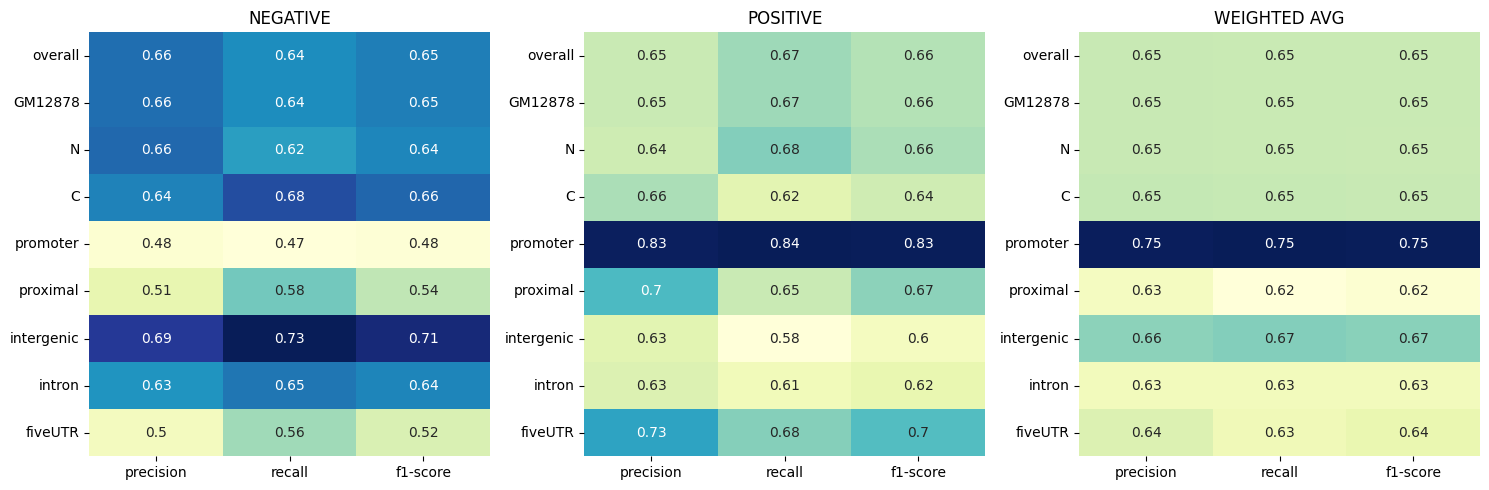

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_neg = neg_eval.drop(columns=['support'])
df_pos = pos_eval.drop(columns=['support'])
df_wavg = weighted_avg_eval.drop(columns=['support'])

# Create subplots with 3 columns and 1 row
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot heatmap for DataFrame 1
sns.heatmap(df_neg, annot=True, cmap="YlGnBu", ax=axs[0], cbar=False)
axs[0].set_title('NEGATIVE')

sns.heatmap(df_pos, annot=True, cmap="YlGnBu", ax=axs[1], cbar=False)
axs[1].set_title('POSITIVE')

# Plot heatmap for DataFrame 3
sns.heatmap(df_wavg, annot=True, cmap="YlGnBu", ax=axs[2], cbar=False)
axs[2].set_title('WEIGHTED AVG')

# Adjust layout
plt.tight_layout()

plt.savefig('modelEval_all.trvl_testingSet_selected_report.pdf')

# Show plot
plt.show()